In [2]:
import numpy as np 
import matplotlib.pyplot as plt

# 2.2.1 Rotation Property of the FT

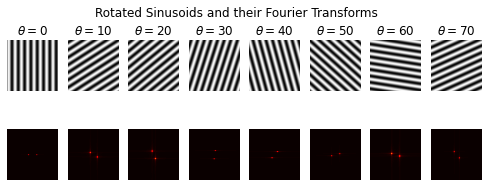

In [189]:
# First we create a 2D sinusoid

nx = 100 
ny = 100 
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y)

f = 4 # we can change this frequency later

Z = np.sin(2*np.pi*f*X)

# We take the FFT of the unrotated sinusoid
Z_fft = np.fft.fft2(Z)
Z_fft_shifted = np.fft.fftshift(Z_fft)
Z_fft_shifted_abs = np.abs(Z_fft_shifted)
# plt.imshow(Z_fft_shifted_abs)

# Now we rotate it and take its FFT

theta_array = [10, 20, 30, 40, 50, 60, 70, 1]  # LAST ELEMENT SHOULD BE A DUMMY and will not matter
                                               # you can maybe fix the indexing but that's your problem
                                               # future me! 
        
Z_rotated_array = np.empty(np.shape(Z))                  # array of rotated sinusoids
Z_rotated_fft_shifted_abs_array = np.empty(np.shape(Z))  # array of rotated sine FTs

for theta in theta_array:
    Z_rotated = np.sin(2*np.pi*f*(Y*np.sin(theta)+(X*np.cos(theta))))  # rotate the sinusoid
    Z_rotated_fft = np.fft.fft2(Z_rotated)
    Z_rotated_fft_shifted = np.fft.fftshift (Z_rotated_fft)
    Z_rotated_fft_shifted_abs = np.abs(Z_rotated_fft_shifted)          # here is the FT
    
    # Now we store with dstack
    Z_rotated_array = np.dstack((Z_rotated, Z_rotated_array))
    Z_rotated_fft_shifted_abs_array = np.dstack((Z_rotated_fft_shifted_abs_array, Z_rotated_fft_shifted_abs))

# Then we plot
fig, ax = plt.subplots(2, len(theta_array))
count = 0 
for i in range(len(theta_array)-1):
    ax[0,0].imshow(Z, cmap='gray')
    ax[0,i+1].imshow(Z_rotated_array[:,:,i], cmap='gray')
    ax[1,0].imshow(Z_fft_shifted_abs, cmap='hot')
    ax[1,i+1].imshow(Z_rotated_fft_shifted_abs_array[:,:,i+1], cmap='hot')
    
    ax[0,0].set_title('$\\theta = 0$')
    ax[0,i+1].set_title('$\\theta = $'+str(theta_array[i]))
    
    
for j in range(2):
    for k in range(len(theta_array)):
        ax[j, k].axis('off')
        
        
fig.suptitle('Rotated Sinusoids and their Fourier Transforms')        
fig.set_size_inches(8.5, 3.0, forward=False)
fig.savefig('Results/Rotating Sinusoid and their FTs',dpi=1000)

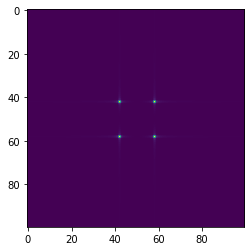

In [195]:
# Now we take the products of sinusoids and observe their FTs

Z_prod1 = (np.sin(2*np.pi*f*X))*(np.sin(2*np.pi*f*Y))
# plt.imshow(Z_prod1, cmap='gray')

Z_prod1_fft = np.fft.fft2(Z_prod1)
Z_prod1_fft_shifted = np.fft.fftshift(Z_prod1_fft)
Z_prod1_fft_shifted_abs = np.abs(Z_prod1_fft_shifted)
plt.imshow(Z_prod1_fft_shifted_abs)
